# --- Data Preparation Orchestrator ---
<p>Data Orchectration script to perform data loading, exploratory analysis, preprocessing, & image augmentation</p>

In [1]:
# ==================
# Libraries
# ==================
import os
import sys
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy
import pandas
import random
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

In [10]:
# =============================
# Create Workspace directory
# =============================
BASE_DIR = Path(os.getcwd()).parent
RAW_DIR = BASE_DIR / "data" / "raw"
INTERIM_DIR = BASE_DIR / "data" / "interim"
PROC_DIR = BASE_DIR / "data" / "processed"

# Connect to custom-defined modules
sys.path.append(str(BASE_DIR))

# Create directory to store raw & processed data
RAW_DIR.mkdir(parents=True, exist_ok=True)
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

# Auto-reload scripts if any changes
%reload_ext autoreload
%autoreload 2

print("Workspace successfully configured.")

Workspace successfully configured.


In [ ]:
# =========================
# Import custom Modules
# =========================
from src.utils.common import get_metadata_from_yaml
from src.data.extractor import KaggleDatasetExtractor
from src.data.analyzer import MultiTaskDatasetProfiler
from src.data.preprocessor import MultiTaskPreprocessor
from src.data.splitter import MultiTaskDataSplitter
from src.utils.data_prep_validator import DatasetSanityChecker

## Step 1: Data Extraction
1. Extract Stream datasets from Kaggle repository.
2. Perform initial analysis on the Raw datasets.

In [4]:
# ===========================
# Extract Stream datasets
# ===========================
# extractor = KaggleDatasetExtractor(download_root=RAW_DIR)
# extractor.download_all()
# extractor.reconstruct_all()

In [5]:
# ============================
# Sample Images of the Stream
# ============================
# for task in ["turnaround", "ppe", "fod"]:
#     folder_path = os.path.join(RAW_DIR, task, "images")
#     images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
#     selected = random.sample(images, min(len(images), 2))
#     fig, axes = plt.subplots(1, 2, figsize=(12, 6))
#     for i, img_name in enumerate(selected):
#         img = cv2.imread(os.path.join(folder_path, img_name))
#         img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#         axes[i].imshow(img_rgb)
#     plt.suptitle(f"{task.upper()} SAMPLE", fontweight="bold", fontsize=16)
#     plt.tight_layout()
#     plt.show()

In [6]:
# =================================
# Initial Analysis on Raw dataset
# =================================
profiler = MultiTaskDatasetProfiler(raw_root=RAW_DIR)
eda_results = profiler.run_initial_eda()

# Render findings cleanly
for task, metrics in eda_results.items():
    print(f"\n==== 📊 Initial Profile for Task: {task.upper()} ====")
    print(f"• Image Count      : {metrics['total_images']}")
    print(f"• Label File Count : {metrics['total_label_files']}")
    print(f"• Class Frequencies: {metrics['raw_class_frequencies']}")
    if metrics['mismatch_warning']:
        print("⚠️ Warning: File count mismatch detected between image arrays and annotations.")


==== 📊 Initial Profile for Task: TURNAROUND ====
• Image Count      : 9740
• Label File Count : 9740
• Class Frequencies: {0: 6346, 1: 2316, 2: 1870, 3: 1793, 4: 956, 5: 4151, 6: 2539, 7: 2071, 8: 21977, 9: 2303, 10: 2964, 11: 4463, 12: 2729}

==== 📊 Initial Profile for Task: PPE ====
• Image Count      : 13140
• Label File Count : 13140
• Class Frequencies: {0: 5876, 1: 9836, 2: 6387, 3: 17402, 4: 16939, 5: 5071, 6: 6522, 7: 10955, 8: 13420, 9: 6871, 10: 8066, 11: 6848, 12: 11800, 13: 6392, 14: 11782, 15: 9340, 16: 6903, 17: 11917}

==== 📊 Initial Profile for Task: FOD ====
• Image Count      : 33793
• Label File Count : 0
• Class Frequencies: {}
⚠️ Warning: File count mismatch detected between image arrays and annotations.


Analyzing distributions across independent domains...


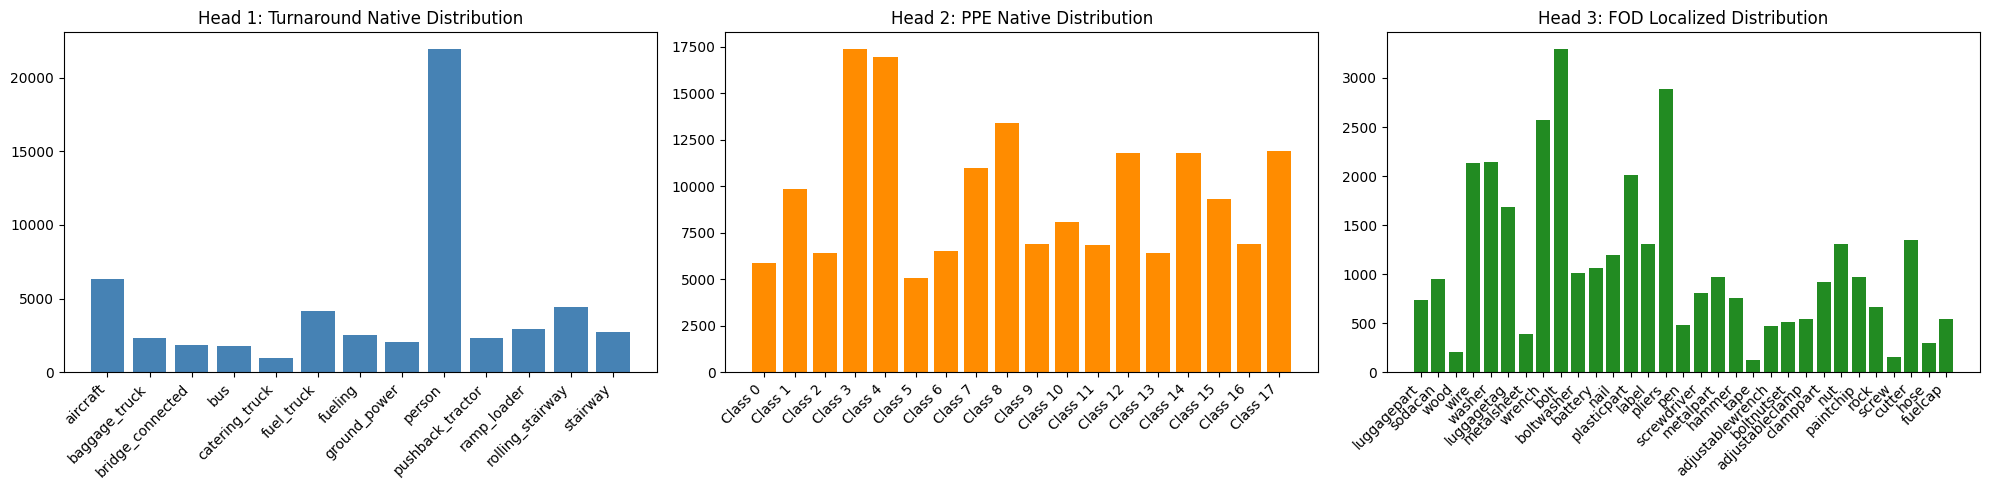


--- FOD Local Mapping Key ---
{'luggagepart': 0, 'sodacan': 1, 'wood': 2, 'wire': 3, 'washer': 4, 'luggagetag': 5, 'metalsheet': 6, 'wrench': 7, 'bolt': 8, 'boltwasher': 9, 'battery': 10, 'nail': 11, 'plasticpart': 12, 'label': 13, 'pliers': 14, 'pen': 15, 'screwdriver': 16, 'metalpart': 17, 'hammer': 18, 'tape': 19, 'adjustablewrench': 20, 'boltnutset': 21, 'adjustableclamp': 22, 'clamppart': 23, 'nut': 24, 'paintchip': 25, 'rock': 26, 'screw': 27, 'cutter': 28, 'hose': 29, 'fuelcap': 30}


In [8]:
# ====================
# Extract Profiles
# ====================
# Get native names from the dataset metadata documentation
turnaround_class_names = get_metadata_from_yaml(os.path.join(RAW_DIR, "turnaround", "data.yaml"))
# Leave ppe_names as None initially to inspect the raw IDs present
ppe_class_names = None

print("Analyzing distributions across independent domains...")
t_dist = profiler.parse_turnaround_classes()
p_dist = profiler.parse_ppe_classes()
f_dist, f_map = profiler.profile_and_convert_fod_classes()

# Plot them side-by-side
profiler.plot_distributions(t_dist, p_dist, f_dist, f_map, t_names=turnaround_class_names, p_names=ppe_class_names)

print("\n--- FOD Local Mapping Key ---")
print(f_map)

<b>Step 1: Analytical Breakdown of the Distributions</b>

<b>Stream 1: Turnaround</b>

* <b>The Reality Check:</b> *person* dominates this dataset with over 20,000 instances, while operational vehicle classes like *fuel_truck* and *catering_truck* are heavily underrepresented (fewer than 2,000 instances).
* <b>The Risk:</b> In the live video stream, the model will highly prone to overlooking incoming service vehicles while focusing entirely on pedestrian crowds.
* <b>The Alignment:</b> Need to keep thses classes distinct to build the custom operational timelines, meaning the *dataset.py* collation module must use loss balancing to ensure the rarer vehicle types caryy higher weight during backpropogation.

<b>Stream 2: PPE</b>

* <b>The Reality Check:</b> This dataset is heavily cluttered with 18 different sequential classes (Class 0 through Class 17).
* <b>The Risk</b> Most of these classes are completely irrelevant to an airfield compliance officer (likely containing generic construction assets like cones, signs, or specialized gear). If we try to train Head 2 on all 18, it will waste precious network capacity on noise, lowering the inference speed on edge hardware.
* <b>The Alignment:</b> Must use a strict filter to isolate <b>only</b> the exact classes corresponding to a person's body, safety vests, and ear protectors, discarding the rest of the array.

<b>Stream 3: FOD</b>

* <b>The Reality Check:</b> This dataset features 30+ micro-classes ranging from *bolt*, *washer*, and *screw* to completely custom elements like *luggagetag* and *paintchip*.
* <b>The Risk:</b> The <b>FOD Detection Head (Head 3)</b> is designed to verify anomalies isolated by the OpenCV background substraction mask. For s safety system, it doesn't matter on the tarmac is a *screw* or a *bolt* - any debris is an immediate hazard that requires a red flag on the dashboard.
* <b>The Alignment:</b> Training the model to differentiate between 30 types of micro-debris will severely bottleneck performance. Will collapse all 30+ classes into a single, highly specialized binary class: *debris_object*.


## Step 2: Data Preprocessing

<b>Head 1 (Turnaround) Output Setup</b>

* <b>Action:</b> Keep the vehicle aircraft sub-classes separated exactly as they appear in the raw data.
* <b>Mathematical Safeguard:</b> To offset the massive spike in the *person* class, we will configure the custom joint loss module (*lossed.py*) to apply focal scaling factors, ensuring the rare vehicles are detected reliably.

<b>Head 2 (PPE) Output Setup</b>

* <b>Action:</b> Identify the specific class IDs for the core safety components. Find the names these 18 raw indices in the local files so we can map the correct ones and ignore the remaining 15 background classes.

<b>Head 3 (FOD) Output Setup</b>

* <b>Action:</b> Build an XML parsing function that intercepts all 30+ string values (like *bolt*, *pliers*, *wire*) and remaps them into a single unified label ID. This creates a highly accurate, single-class detection head for Stream C.

In [9]:
# ======================
# Remap configurations
# ======================
# Print the required PPE equipment raw index
raw_ppe_classes = get_metadata_from_yaml(os.path.join(RAW_DIR, "ppe", "data.yaml"))
for i, obj in enumerate(raw_ppe_classes):
    if obj == "Ear Protectors" or obj == "Safety Vest":
        print(f"{obj}: {i}")


Ear Protectors: 0
Safety Vest: 8


<b>Preprocessor Pipeline</b>
<p>Handles the uniform 640 x 640 letterboxing, performs Pascal VOC to local YOLO conversion for FOD, drops the 12 unwanted PPE classes, and outputs three distinct target structures.</p>

In [11]:
# ===============================
# Preprocessing to Interim Cache
# ===============================
print("🚀 [Step 1/2] Processing raw streams to 'data/interim'...")
preprocessor = MultiTaskPreprocessor(raw_dir = RAW_DIR, interim_dir = INTERIM_DIR)

interim_summary = preprocessor.process_all_streams()

print("\n📊 ----- Interim Ingestion Complete -----")
for stream, count in interim_summary.items():
    print(f"• Stream: {stream.upper():12} | Successfully Cached: {count} samples")

🚀 [Step 1/2] Processing raw streams to 'data/interim'...



📊 ----- Interim Ingestion Complete -----
• Stream: TURNAROUND   | Successfully Cached: 9733 samples
• Stream: PPE          | Successfully Cached: 8059 samples
• Stream: FOD          | Successfully Cached: 33793 samples


In [12]:
# ================================================
# Stratified Partitioning to Processed Directory
# ================================================
print("🚀 [Step 2/2] Running individual stratified splits (70:15:15)...")
splitter = MultiTaskDataSplitter(interim_dir = INTERIM_DIR, processed_dir = PROC_DIR)

split_summary = splitter.execute_splits()

print("\n📊 ----- Split & Stratification Complete -----")
for stream, splits in split_summary.items():
    print(f"• Stream: {stream.upper():12} | Train: {splits['train']:5} | Val: {splits['val']:4} | Test: {splits['test']:4}")

🚀 [Step 2/2] Running individual stratified splits (70:15:15)...



📊 ----- Split & Stratification Complete -----
• Stream: TURNAROUND   | Train:  6813 | Val: 1460 | Test: 1460
• Stream: PPE          | Train:  5641 | Val: 1209 | Test: 1209
• Stream: FOD          | Train: 23655 | Val: 5069 | Test: 5069


In [14]:
# =================================
# Data Preparation Sanity Check
# =================================
print("🔍 Initializing global data sanity checks across all target directories...")
checker = DatasetSanityChecker(processed_dir=PROC_DIR)

total_images, validation_errors = checker.check_integrity()

print("\n📋 ================= DATA SANITY CHECK REPORT =================")
print(f"Total structured image-label pairs evaluated: {total_images}")

if not validation_errors:
    print("\n✅ SUCCESS: All splits passed validation rules!")
    print("• Perfect 1:1 image-to-label configuration.")
    print("• All coordinates strictly normalized inside bounding box limits.")
    print("• Localized streams map perfectly to designated target heads.")
    print("\n📦 Data pipeline complete!")
else:
    print(f"\n🚨 FOUND {len(validation_errors)} PIPELINE ANOMALIES:\n")
    # Display the first 10 errors to keep the console scannable
    for err in validation_errors[:10]:
        print(err)
    if len(validation_errors) > 10:
        print(f"\n... and {len(validation_errors) - 10} more errors. Review label generation logs.")

🔍 Initializing global data sanity checks across all target directories...

📋 ================= DATA SANITY CHECK REPORT =================
Total structured image-label pairs evaluated: 51585

✅ SUCCESS: All splits passed validation rules!
• Perfect 1:1 image-to-label configuration.
• All coordinates strictly normalized inside bounding box limits.
• Localized streams map perfectly to designated target heads.

📦 Data pipeline complete!
